In [1]:
import os
import json
import numpy as np
import librosa

In [2]:
# Define Correct Paths
BASE_PATH = "/kaggle/input/datasets/accelotron/nsynth-wav/nsynth-train-all"

AUDIO_PATH = os.path.join(BASE_PATH, "audio")
JSON_PATH = os.path.join(BASE_PATH, "examples-train-original.json")

print("Audio Path Exists:", os.path.exists(AUDIO_PATH))
print("JSON Path Exists:", os.path.exists(JSON_PATH))

Audio Path Exists: True
JSON Path Exists: True


In [3]:
#Load JSON Metadata
with open(JSON_PATH, "r") as f:
    metadata = json.load(f)

print("Total samples in JSON:", len(metadata))

Total samples in JSON: 289205


In [4]:
# Select Few Instruments

# selected_families = ["keyboard", "guitar", "bass", "string"]

# filtered_files = []

# for file_id, info in metadata.items():
#     if info["instrument_family_str"] in selected_families:
#         filtered_files.append((file_id, info["instrument_family_str"]))

# print("Filtered samples:", len(filtered_files))


# # # Create label mapping
# # selected_families = ["keyboard", "guitar", "bass", "string"]

# # label_map = {name: idx for idx, name in enumerate(selected_families)}

# # print(label_map)

# selected_families = ["keyboard", "guitar", "bass", "string"]

# label_map = {name: idx for idx, name in enumerate(selected_families)}

# print(label_map)


# Select Few Instruments
selected_families = ["keyboard", "guitar", "bass", "string"]

filtered_files = []

for file_id, info in metadata.items():
    if info["instrument_family_str"] in selected_families:
        filtered_files.append((file_id, info["instrument_family_str"]))

print("Filtered samples:", len(filtered_files))

# Create label mapping
label_map = {name: idx for idx, name in enumerate(selected_families)}

print(label_map)

Filtered samples: 169459
{'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3}


In [5]:
# Load One Audio File
file_id, label = filtered_files[100]

file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

audio, sr = librosa.load(file_path, sr=None)

print("Sampling Rate:", sr)
print("Audio Shape:", audio.shape)
print("Label:", label)

Sampling Rate: 16000
Audio Shape: (64000,)
Label: keyboard


In [6]:
# Trim Silence
audio_trimmed, _ = librosa.effects.trim(audio)

print("Original length:", len(audio))
print("Trimmed length:", len(audio_trimmed))

Original length: 64000
Trimmed length: 52224


In [7]:
# RMS Normalization
def rms_normalize(signal, target_rms=0.1):
    rms = np.sqrt(np.mean(signal**2))
    return signal * (target_rms / rms)

audio_normalized = rms_normalize(audio_trimmed)

# Check new RMS
new_rms = np.sqrt(np.mean(audio_normalized**2))
print("New RMS:", new_rms)

New RMS: 0.10000002


In [8]:
# Convert Audio → Mel-Spectrogram

import matplotlib.pyplot as plt
import librosa.display

mel_spec = librosa.feature.melspectrogram(
    y=audio_normalized,
    sr=sr,
    n_mels=128
)

print("Mel Spectrogram Shape:", mel_spec.shape)


Mel Spectrogram Shape: (128, 103)


In [9]:
# Apply Log Scaling (Convert to dB)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("After Log Scaling Shape:", mel_spec_db.shape)

After Log Scaling Shape: (128, 103)


In [10]:
# Feature Standardization

mean = np.mean(mel_spec_db)
std = np.std(mel_spec_db)

mel_spec_std = (mel_spec_db - mean) / std

print("New Mean:", np.mean(mel_spec_std))
print("New Std:", np.std(mel_spec_std))

New Mean: -3.3332307e-07
New Std: 1.0


In [11]:
# Appling above processing to the large files..

X = []
Y = []

fixed_length = 128  # target time frames

for file_id, label in filtered_files[:100]:
    
    file_path = os.path.join(AUDIO_PATH, file_id + ".wav")
    
    audio, sr = librosa.load(file_path, sr=16000)
    
    audio, _ = librosa.effects.trim(audio)
    
    audio = rms_normalize(audio)
    
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )
    
    mel_db = librosa.power_to_db(mel, ref=np.max)
    
    # Standardize
    mel_db = (mel_db - np.mean(mel_db)) / np.std(mel_db)
    
    # 🔥 Fix size here
    if mel_db.shape[1] < fixed_length:
        pad_width = fixed_length - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0, 0), (0, pad_width)), mode='constant')
    else:
        mel_db = mel_db[:, :fixed_length]
    
    X.append(mel_db)
    Y.append(label_map[label])

print("Processed samples:", len(X))


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1536
  warnings.warn(


Processed samples: 100


In [12]:
# Convert Labels to Numbers

# Create label mapping
label_map = {name: idx for idx, name in enumerate(selected_families)}

print("Label Map:", label_map)

Label Map: {'keyboard': 0, 'guitar': 1, 'bass': 2, 'string': 3}


In [13]:
X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (100, 128, 128)
Y shape: (100,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)


print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (80, 128, 128)
Validation: (10, 128, 128)
Test: (10, 128, 128)


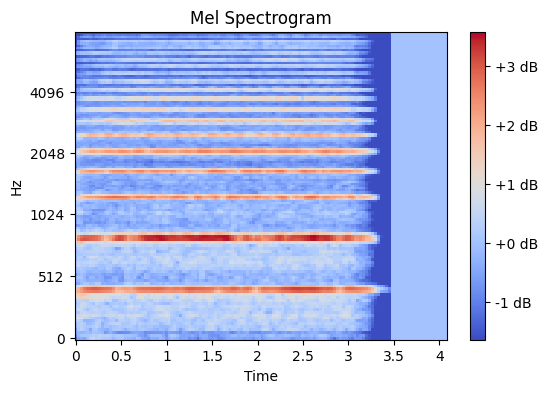

In [28]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(6, 4))
librosa.display.specshow(X_train[50].squeeze(), 
                         sr=16000, 
                         x_axis='time', 
                         y_axis='mel')

plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.show()

File: keyboard_electronic_087-092-050
Label: keyboard
MFCC Shape: (13, 126)


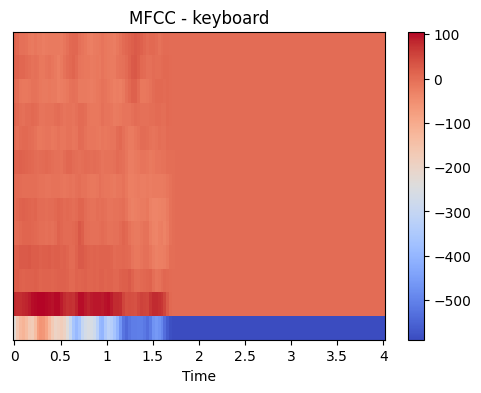

In [16]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

# Choose audio index
index = 10   # change this to view different audio

file_id, label = filtered_files[index]
file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

# Load audio directly
audio, sr = librosa.load(file_path, sr=16000)

# Generate MFCC
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13
)

print("File:", file_id)
print("Label:", label)
print("MFCC Shape:", mfcc.shape)

# Display MFCC
plt.figure(figsize=(6,4))
librosa.display.specshow(mfcc,
                         sr=sr,
                         x_axis='time')
plt.colorbar()
plt.title(f"MFCC - {label}")
plt.show()


In [19]:
# Choose Audio

index = 50  # I can choose any index

file_id, label = filtered_files[index]
file_path = os.path.join(AUDIO_PATH, file_id + ".wav")

audio, sr = librosa.load(file_path, sr=16000)

print("File:", file_id)
print("Label:", label)

File: guitar_electronic_034-012-100
Label: guitar


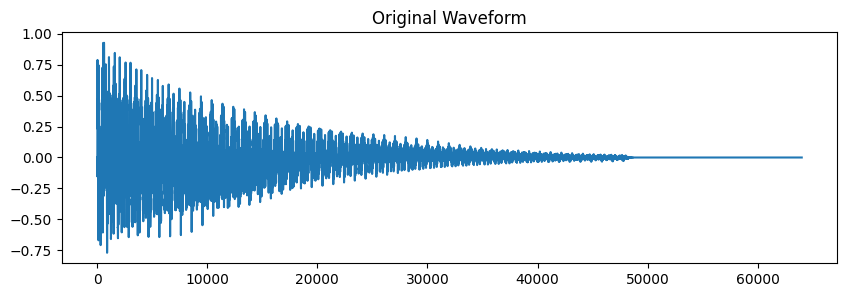

In [20]:
# Show Original Waveform

import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(audio)
plt.title("Original Waveform")
plt.show()

In [21]:
# Applied two Augmentation...

#Pitch shifting
audio_pitch = librosa.effects.pitch_shift(audio, sr=sr, n_steps=1)


# Adding background noise
noise = 0.005 * np.random.randn(len(audio))
audio_noise = audio + noise

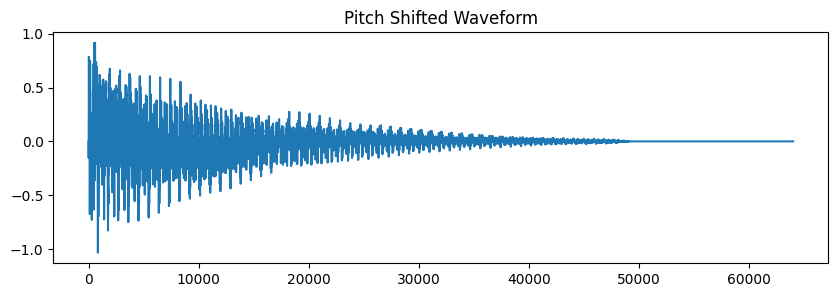

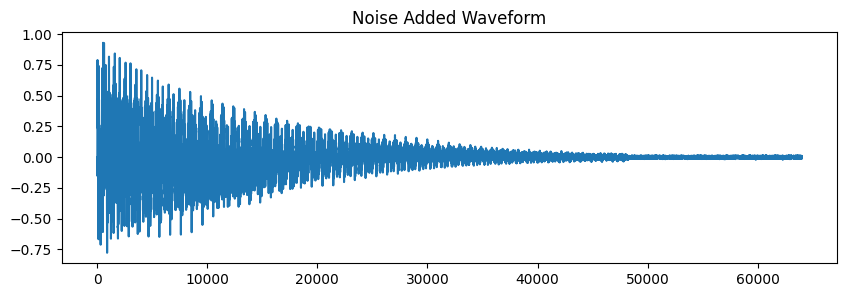

In [22]:
# Showing Augmented Waveforms

plt.figure(figsize=(10,3))
plt.plot(audio_pitch)
plt.title("Pitch Shifted Waveform")
plt.show()

plt.figure(figsize=(10,3))
plt.plot(audio_noise)
plt.title("Noise Added Waveform")
plt.show()

In [25]:
# Generate Spectrograms of Augmented Waveforms

def plot_mel(audio_signal, title):
    mel = librosa.feature.melspectrogram(y=audio_signal, sr=sr, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    plt.figure(figsize=(6,4))
    librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar()
    plt.title(title)
    plt.show()

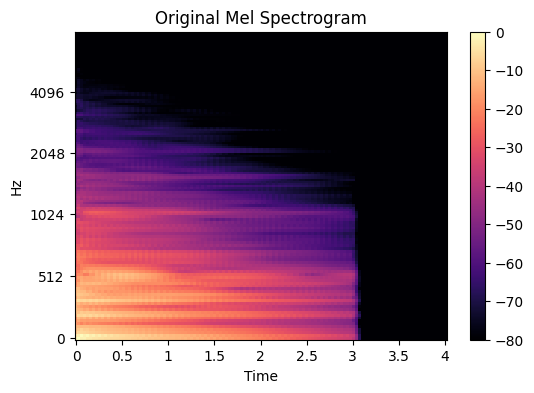

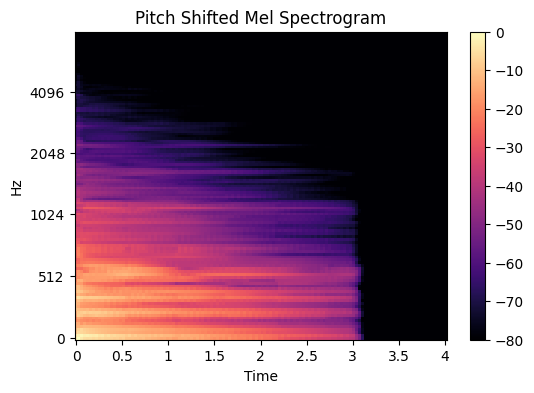

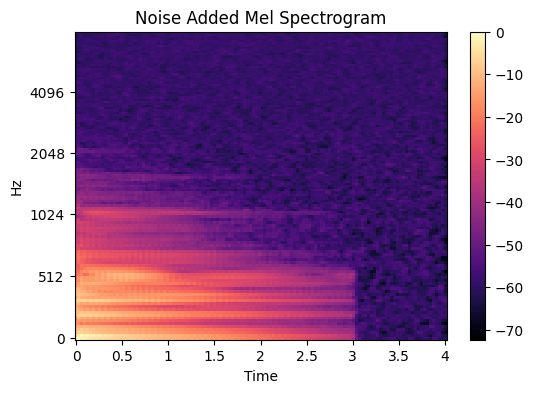

In [26]:
plot_mel(audio, "Original Mel Spectrogram")
plot_mel(audio_pitch, "Pitch Shifted Mel Spectrogram")
plot_mel(audio_noise, "Noise Added Mel Spectrogram")

## My observation

After applying pitch shifting, the harmonic structure in the spectrogram shifted slightly upward in frequency while maintaining the overall timbre pattern.

After adding background noise, the waveform showed small fluctuations and the spectrogram displayed mild background energy increase.

Overall, the augmentation techniques introduced controlled variations without altering the fundamental identity of the instrument, thereby enhancing data diversity while maintaining label consistency.